<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/10_report_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
!pip install shap -q
import numpy as np, pandas as pd, joblib, pickle, shap, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.metrics import confusion_matrix, roc_curve, auc
import builtins; print = builtins.print
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'

plt.rcParams.update({'figure.dpi':300,'savefig.dpi':300,'font.size':12,
                     'axes.titlesize':14,'axes.labelsize':12,'figure.facecolor':'white'})
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [2]:
# CELL 2 — Load everything
model_comparison = pd.read_csv(f'{BASE}/results/metrics/model_comparison.csv')
xai_comparison   = pd.read_csv(f'{BASE}/results/metrics/xai_comparison.csv')
shift_results    = pd.read_csv(f'{BASE}/results/metrics/distribution_shift.csv')
bootstrap_ci     = pd.read_csv(f'{BASE}/results/metrics/bootstrap_ci.csv')

with open(f'{BASE}/results/shap_values.pkl','rb') as f: shap_data = pickle.load(f)
rf_model = joblib.load(f'{BASE}/results/models/random_forest.pkl')
data = joblib.load(f'{BASE}/data/processed/nsl_kdd_processed.pkl')
X_test = data['X_test']; y_test = data['y_test']

shap_class1   = shap_data['shap_class1']
feature_names = shap_data['feature_names']
X_shap        = shap_data['data']

print('✅ All data loaded')
print(f'   SHAP: {shap_class1.shape} with {len(feature_names)} named features')

✅ All data loaded
   SHAP: (200, 41) with 41 named features


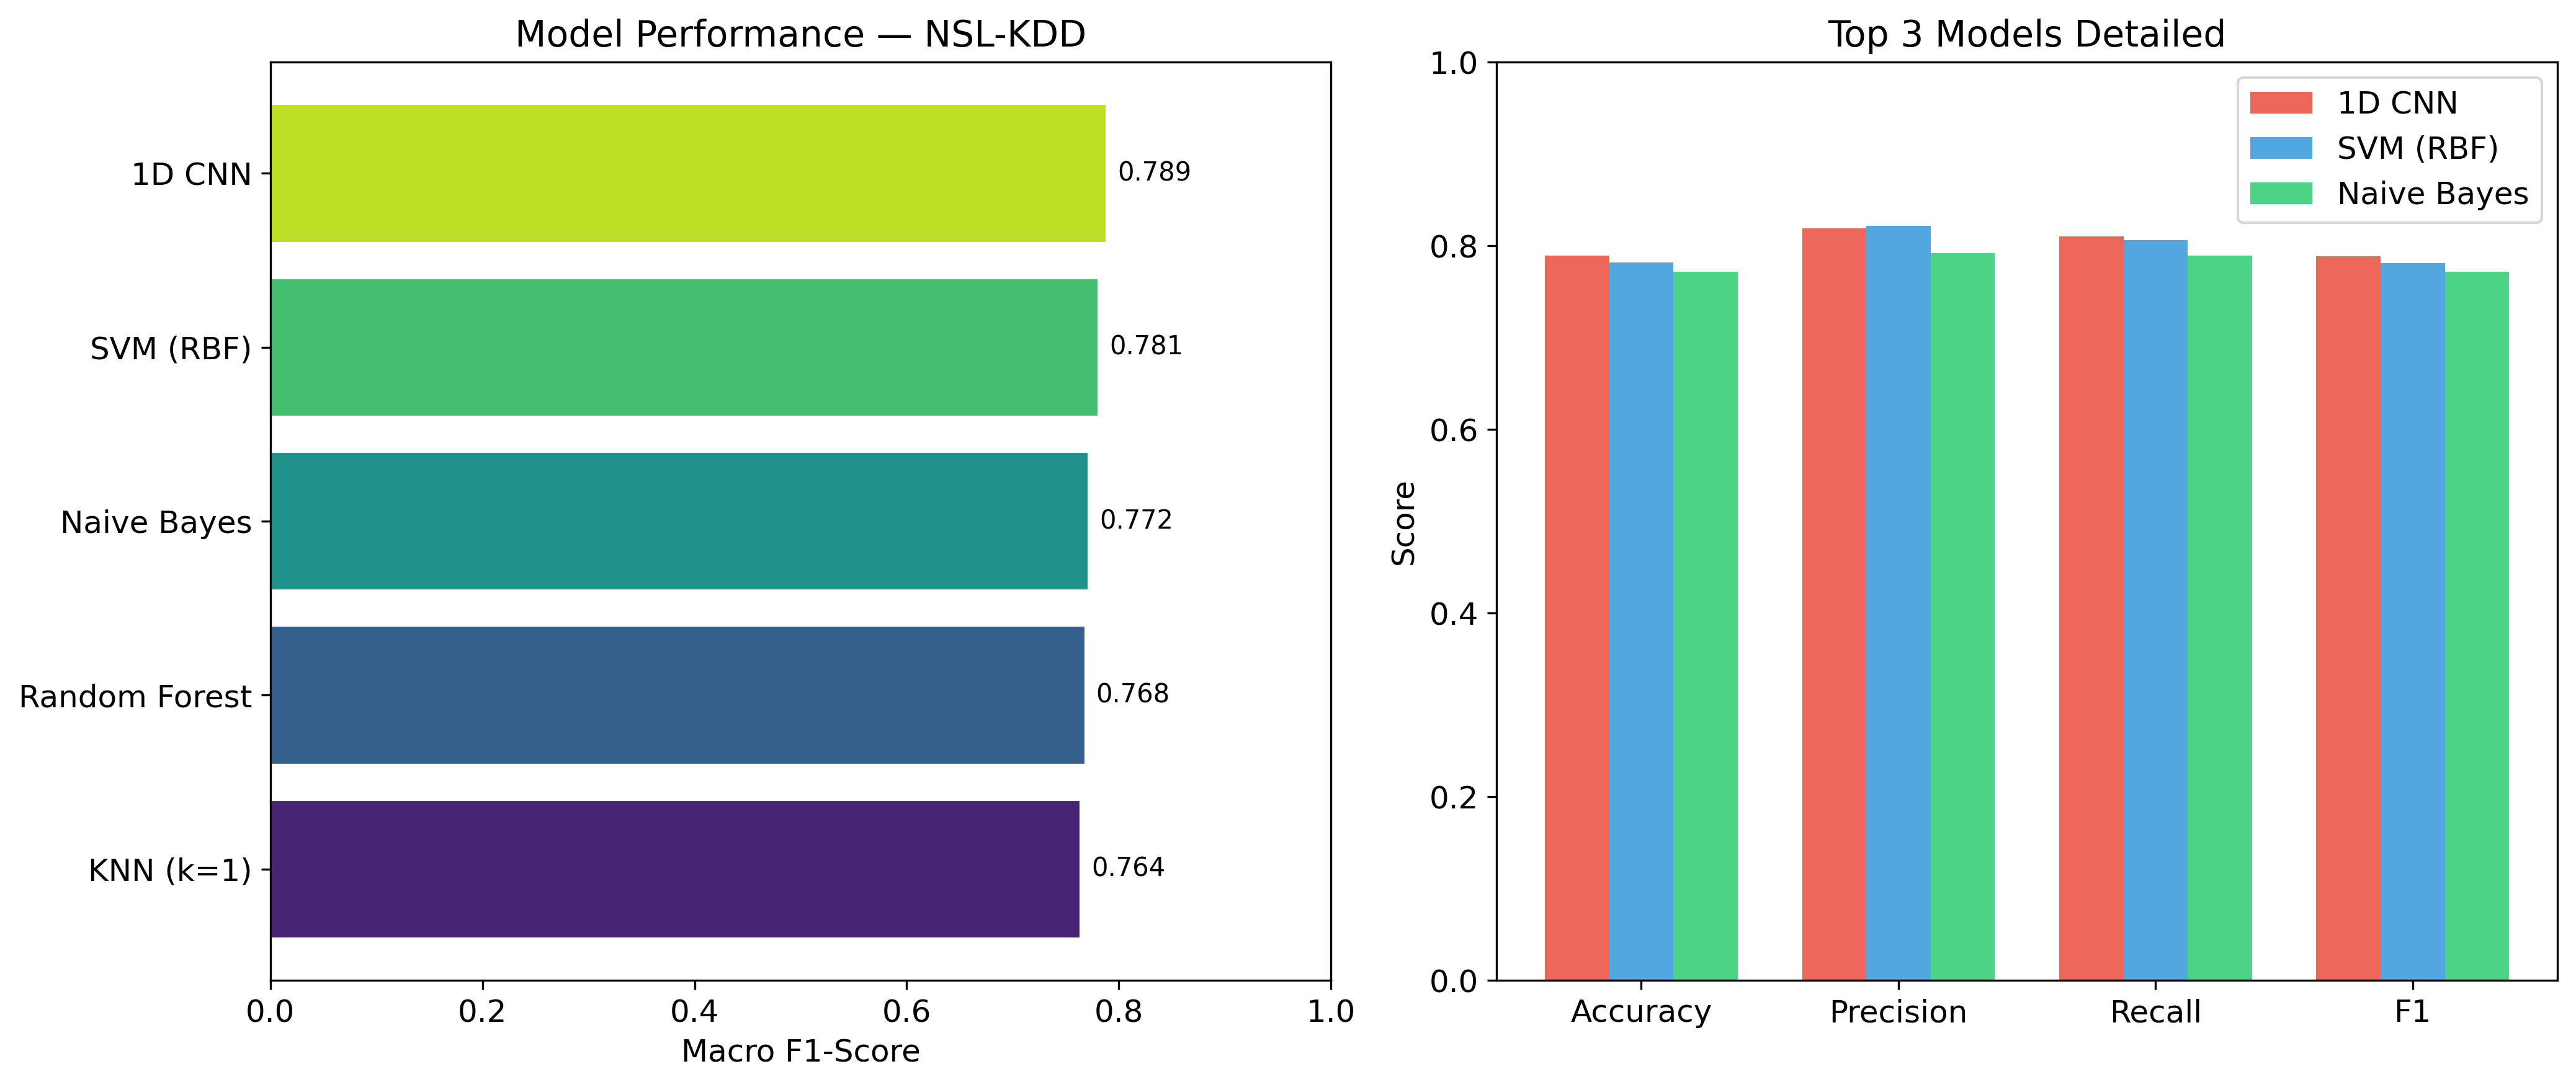

✅ Fig 1 saved


In [3]:
# CELL 3 — Fig 1: Model comparison
fig, axes = plt.subplots(1,2,figsize=(14,6))
mc = model_comparison.sort_values('test_f1')
colors = plt.cm.viridis(np.linspace(0.1,0.9,len(mc)))
bars = axes[0].barh(mc['model'], mc['test_f1'], color=colors, edgecolor='white')
axes[0].set_xlabel('Macro F1-Score'); axes[0].set_title('Model Performance — NSL-KDD'); axes[0].set_xlim(0,1)
for bar, score in zip(bars, mc['test_f1']):
    axes[0].text(score+0.01, bar.get_y()+bar.get_height()/2, f'{score:.3f}', va='center', fontsize=10)

top3 = model_comparison.nlargest(3,'test_f1')
x = np.arange(4); w = 0.25; c3 = ['#e74c3c','#3498db','#2ecc71']
for i, (_,row) in enumerate(top3.iterrows()):
    axes[1].bar(x+i*w,[row[m] for m in ['test_accuracy','test_precision','test_recall','test_f1']],w,label=row['model'],color=c3[i],alpha=0.85)
axes[1].set_xticks(x+w); axes[1].set_xticklabels(['Accuracy','Precision','Recall','F1'])
axes[1].set_ylabel('Score'); axes[1].set_title('Top 3 Models Detailed'); axes[1].legend(); axes[1].set_ylim(0,1)
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig1_model_comparison.png',bbox_inches='tight')
plt.show(); print('✅ Fig 1 saved')

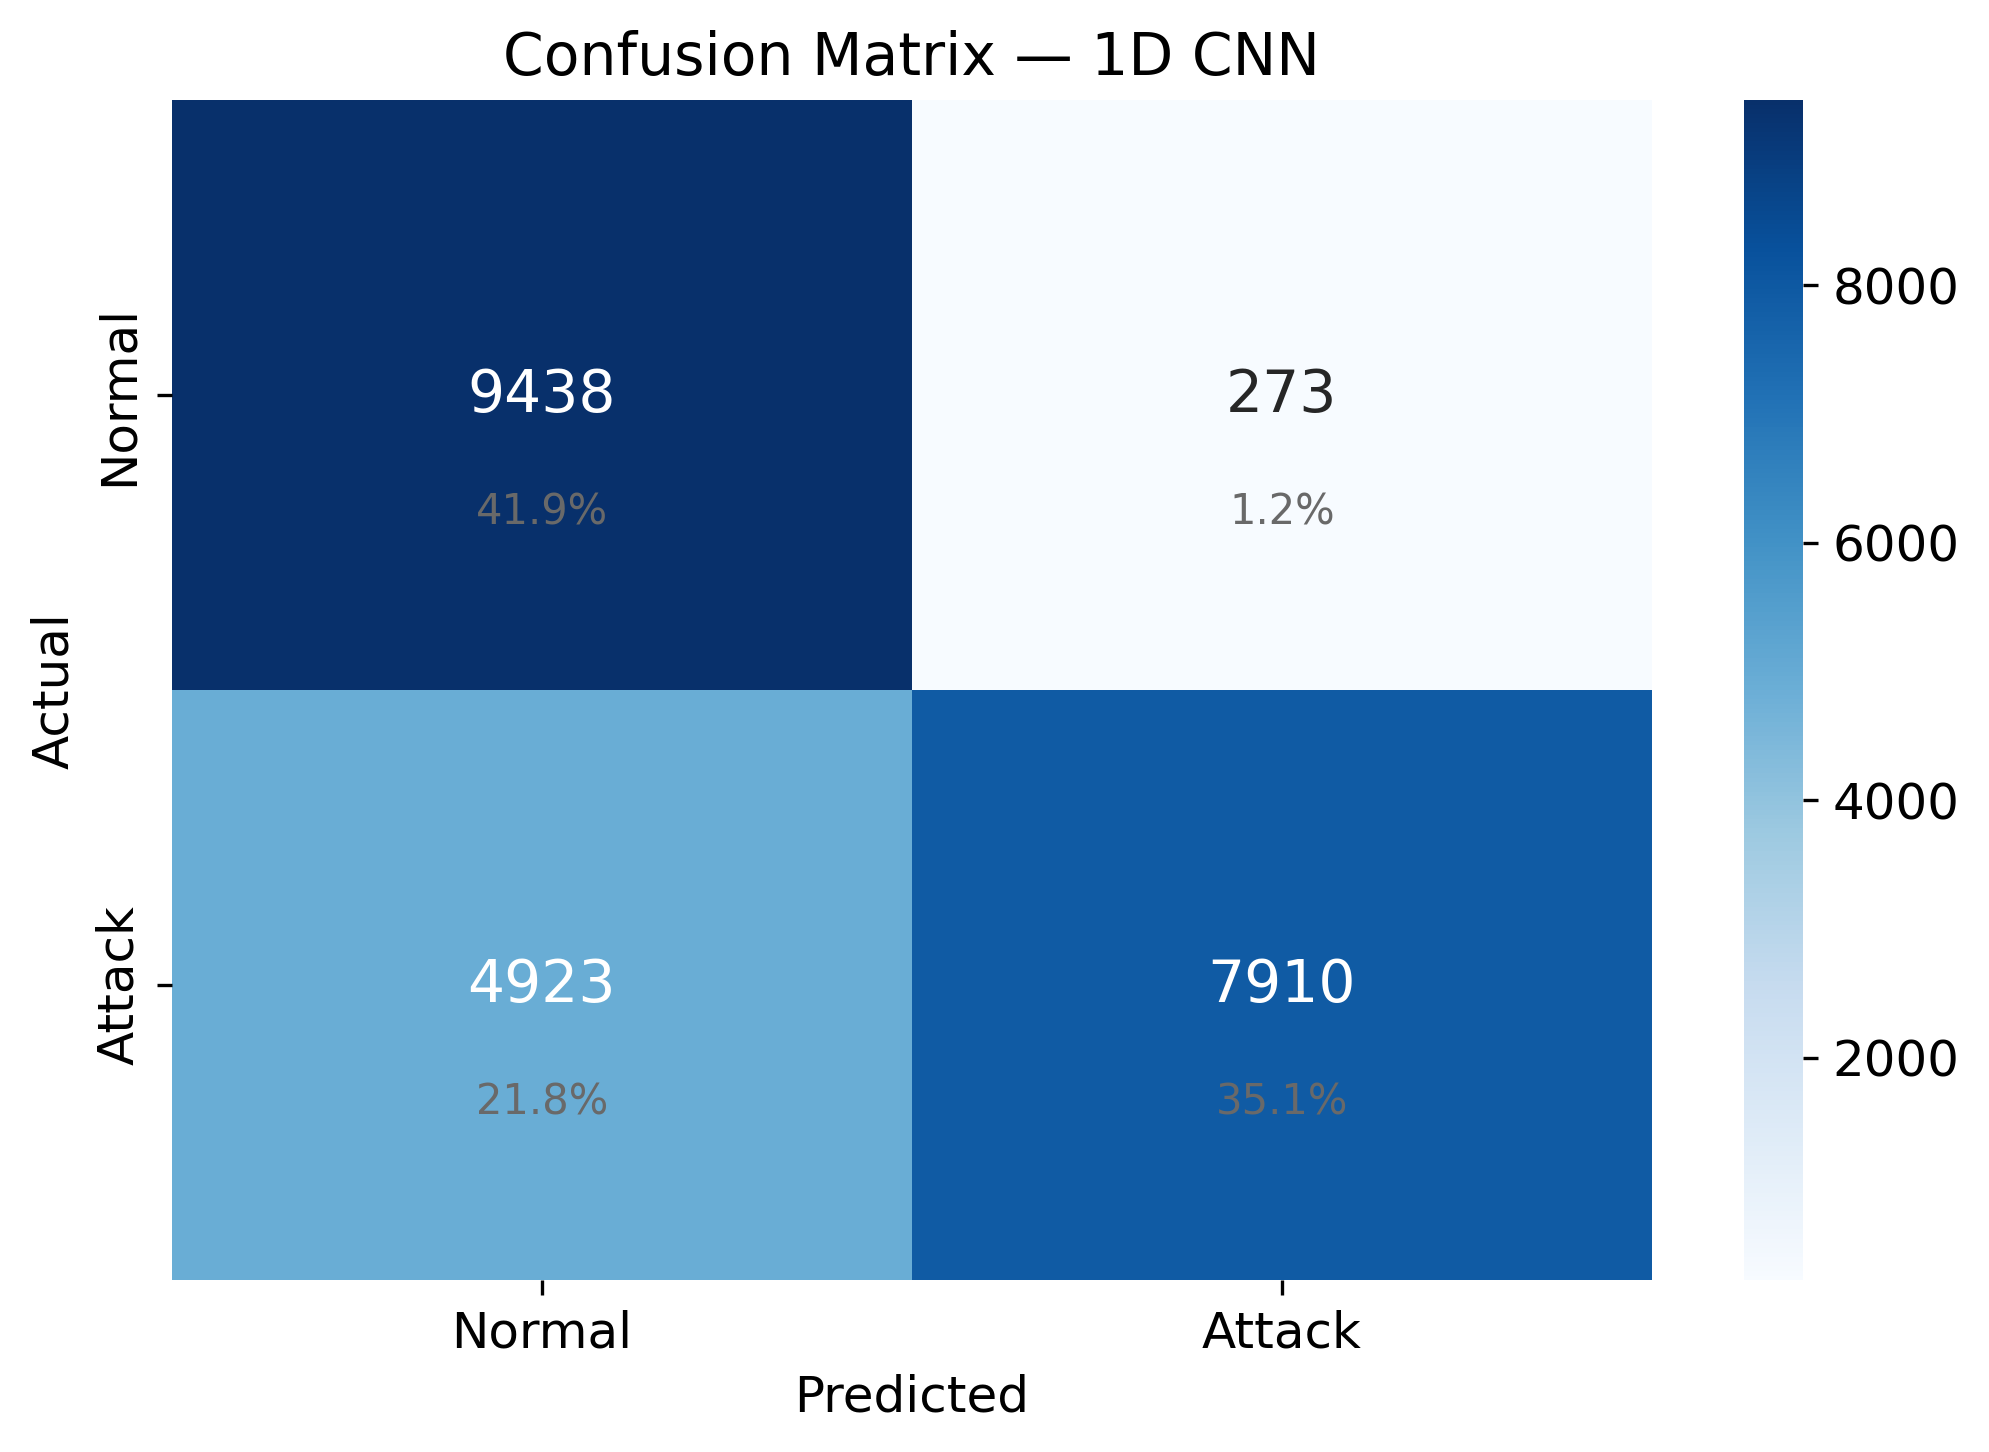

✅ Fig 2 saved


In [4]:
# CELL 4 — Fig 2: Confusion matrix
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
best_name = model_comparison.loc[model_comparison['test_f1'].idxmax(),'model']
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'], annot_kws={'size':14})
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'{cm[i,j]/cm.sum():.1%}', ha='center', color='dimgray', fontsize=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig2_confusion_matrix.png',bbox_inches='tight')
plt.show(); print('✅ Fig 2 saved')

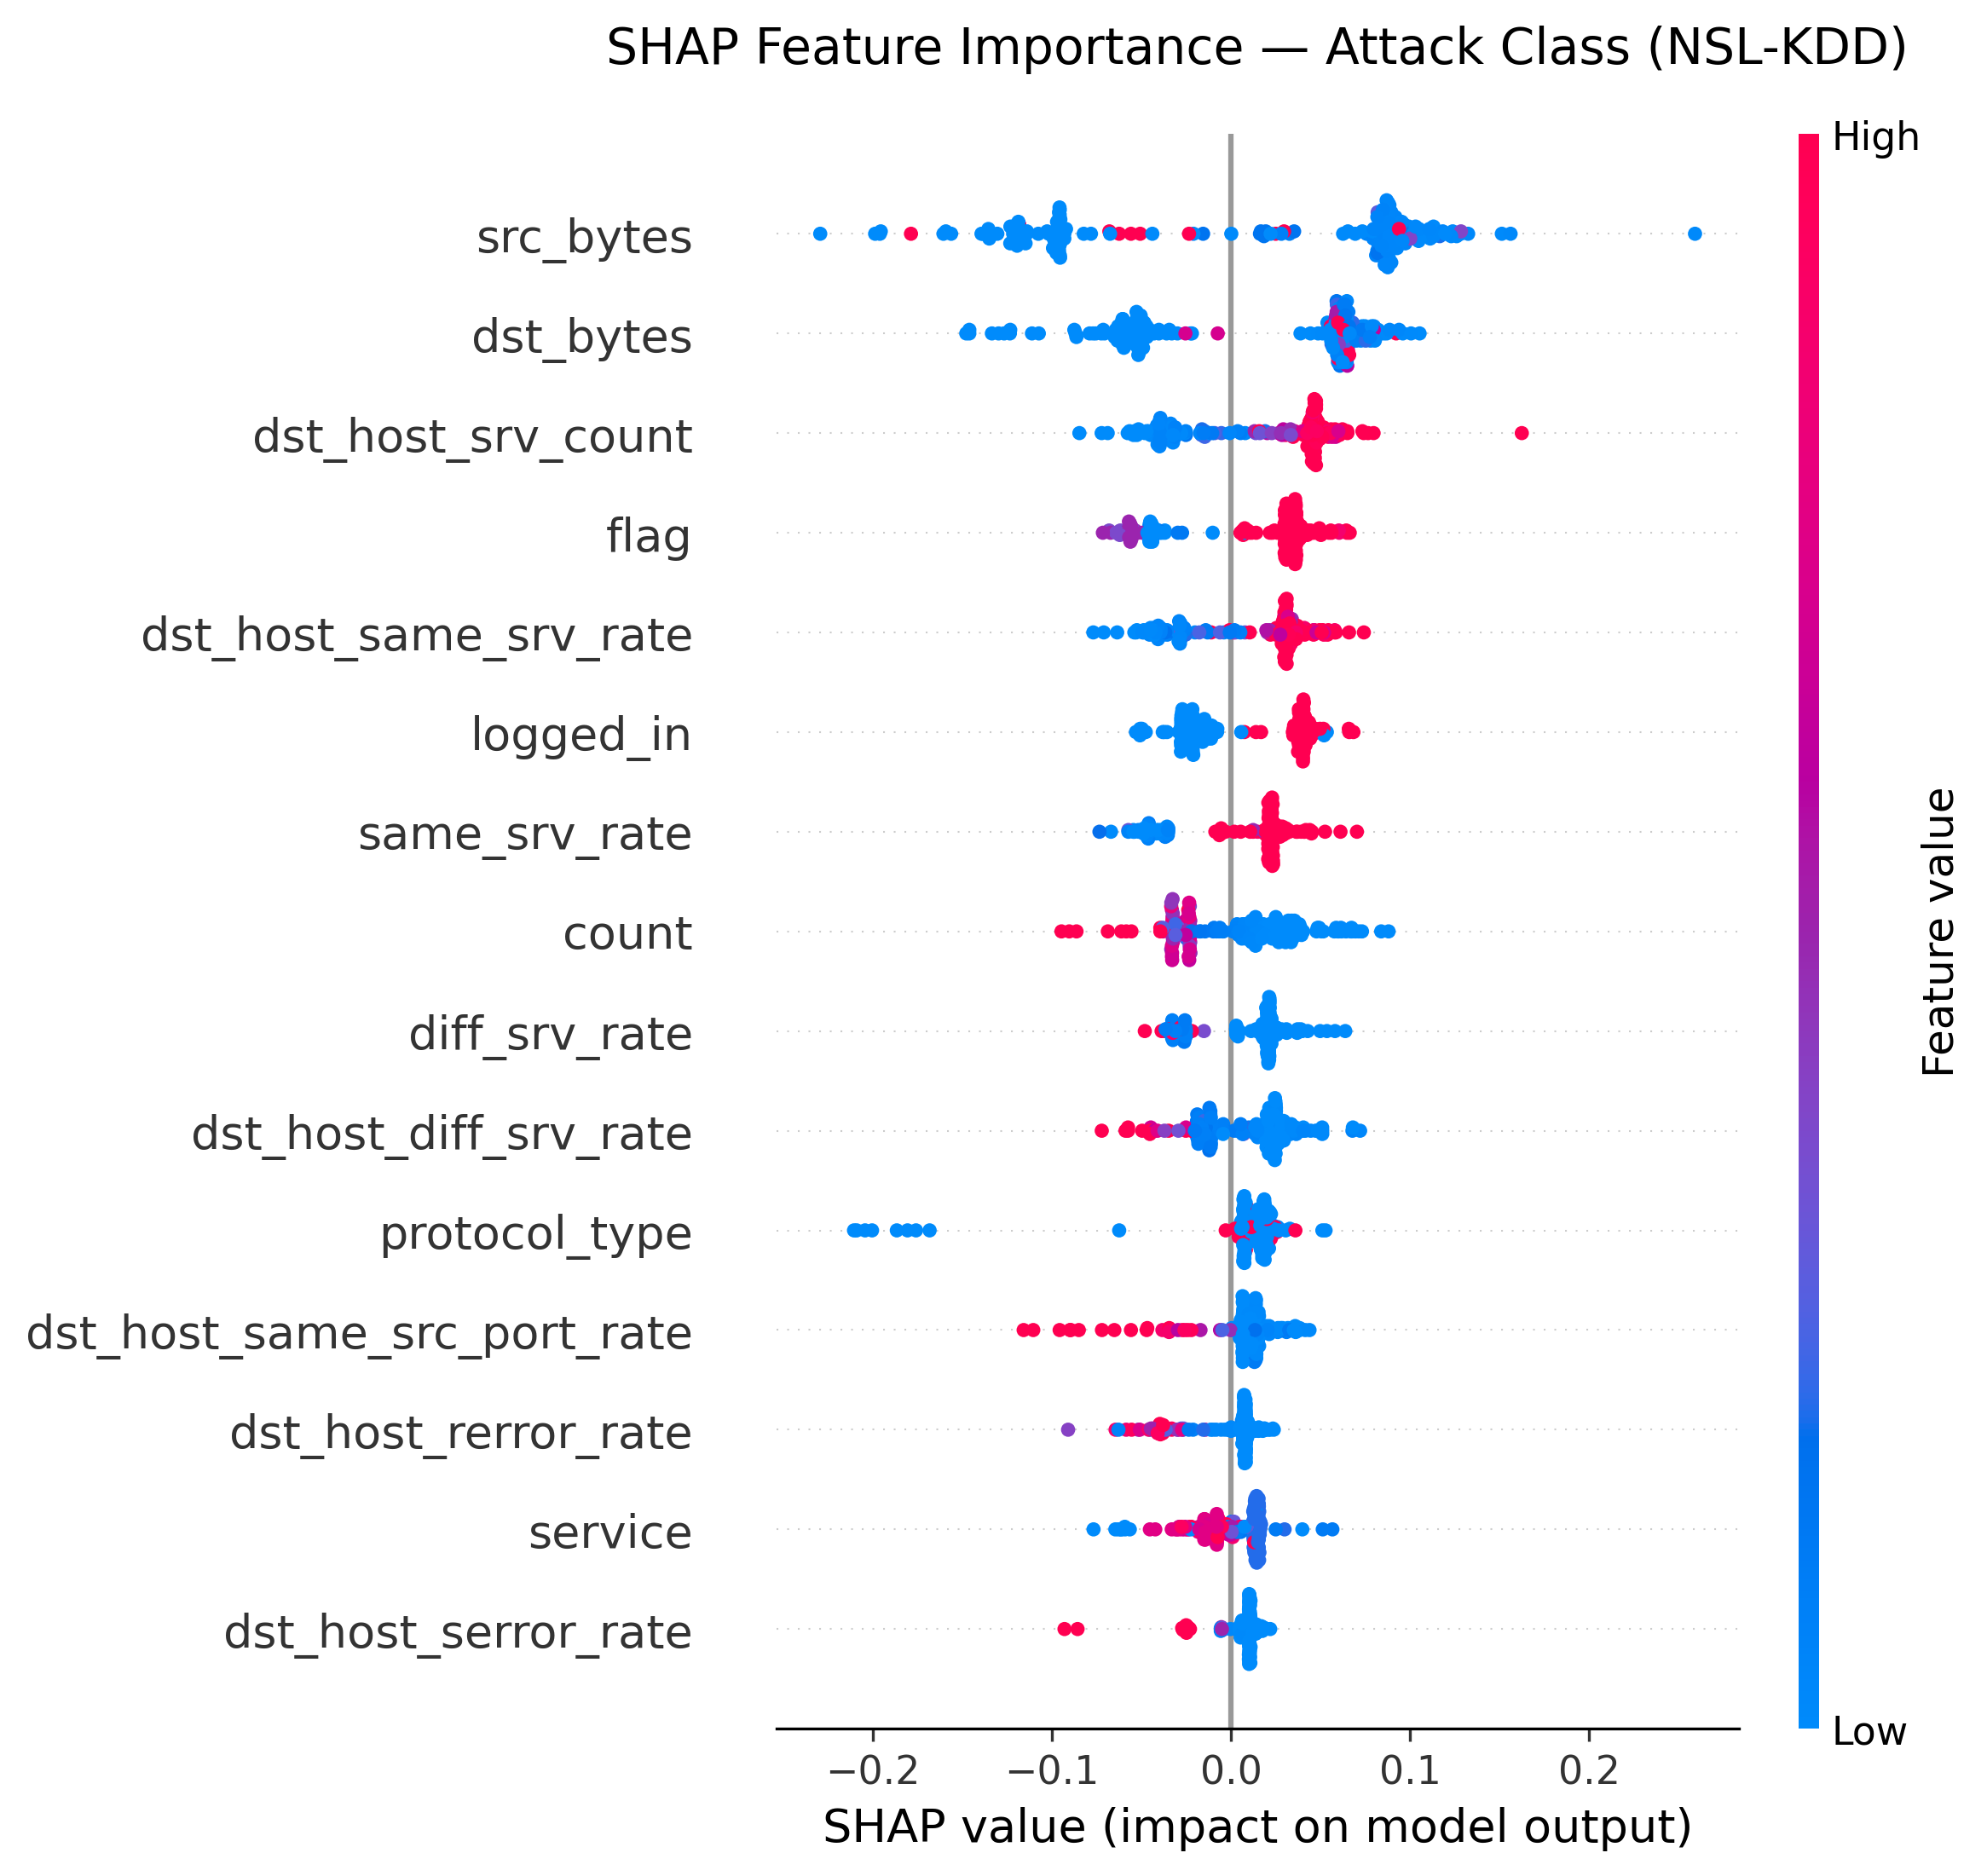

✅ Fig 3 saved (real feature names)


In [5]:
# CELL 5 — Fig 3: SHAP (fixed — real feature names, correct array)
fig, ax = plt.subplots(figsize=(12,9))
shap.summary_plot(shap_class1, X_shap, feature_names=feature_names, max_display=15, show=False)
plt.title('SHAP Feature Importance — Attack Class (NSL-KDD)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/report_fig3_shap_summary.png', bbox_inches='tight')
plt.show(); print('✅ Fig 3 saved (real feature names)')

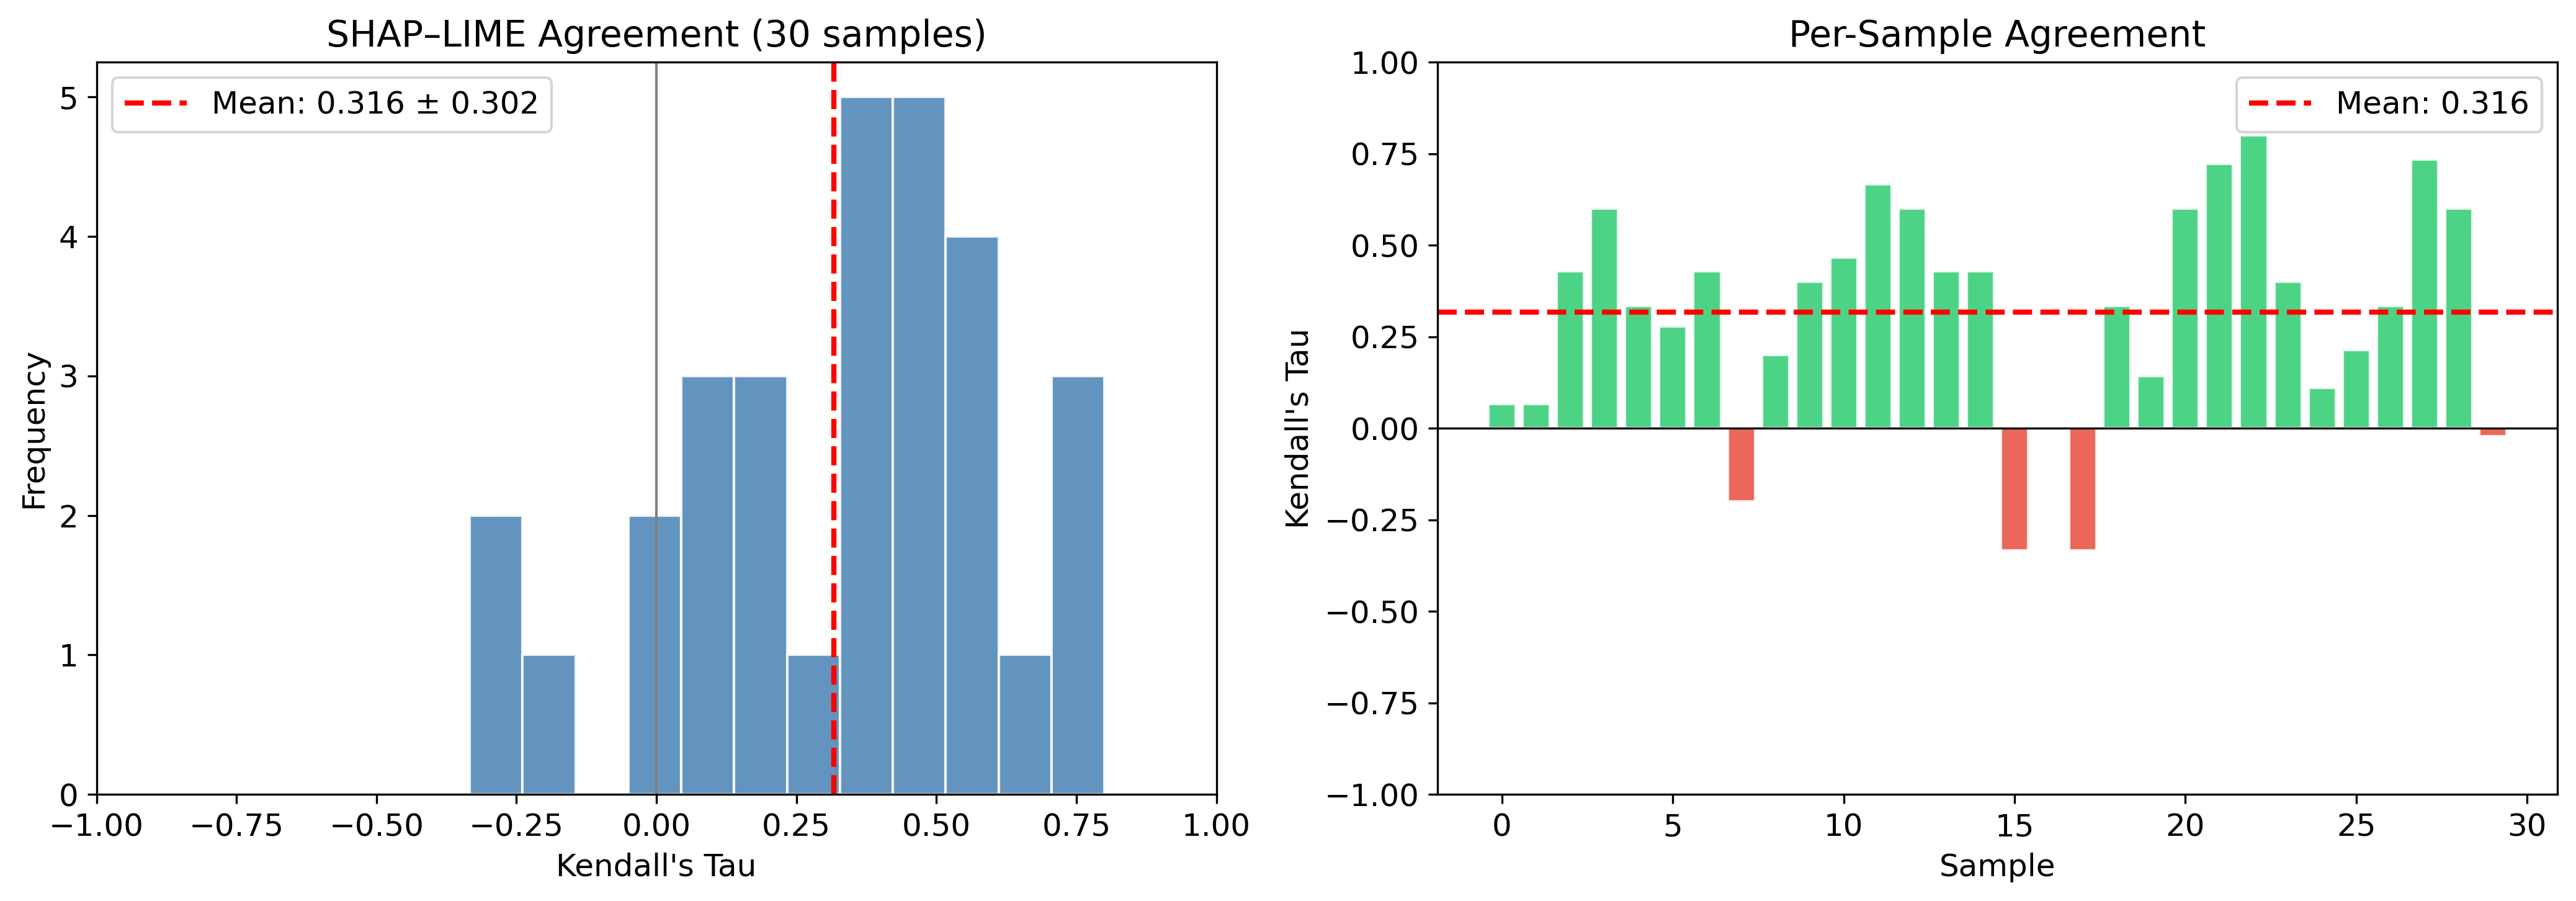

✅ Fig 4 saved


In [6]:
# CELL 6 — Fig 4: SHAP vs LIME
tau_mean = xai_comparison['kendall_tau'].mean()
tau_std  = xai_comparison['kendall_tau'].std()
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(xai_comparison['kendall_tau'], bins=12, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(tau_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tau_mean:.3f} ± {tau_std:.3f}')
axes[0].axvline(0, color='grey', linewidth=1)
axes[0].set_xlabel("Kendall's Tau"); axes[0].set_ylabel('Frequency')
axes[0].set_title(f'SHAP–LIME Agreement ({len(xai_comparison)} samples)'); axes[0].set_xlim(-1,1); axes[0].legend()
bc_arr = ['#2ecc71' if t>0 else '#e74c3c' for t in xai_comparison['kendall_tau']]
axes[1].bar(xai_comparison['sample'], xai_comparison['kendall_tau'], color=bc_arr, edgecolor='white', alpha=0.85)
axes[1].axhline(tau_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tau_mean:.3f}')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel("Kendall's Tau"); axes[1].set_title('Per-Sample Agreement')
axes[1].set_ylim(-1,1); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig4_shap_vs_lime.png',bbox_inches='tight')
plt.show(); print('✅ Fig 4 saved')

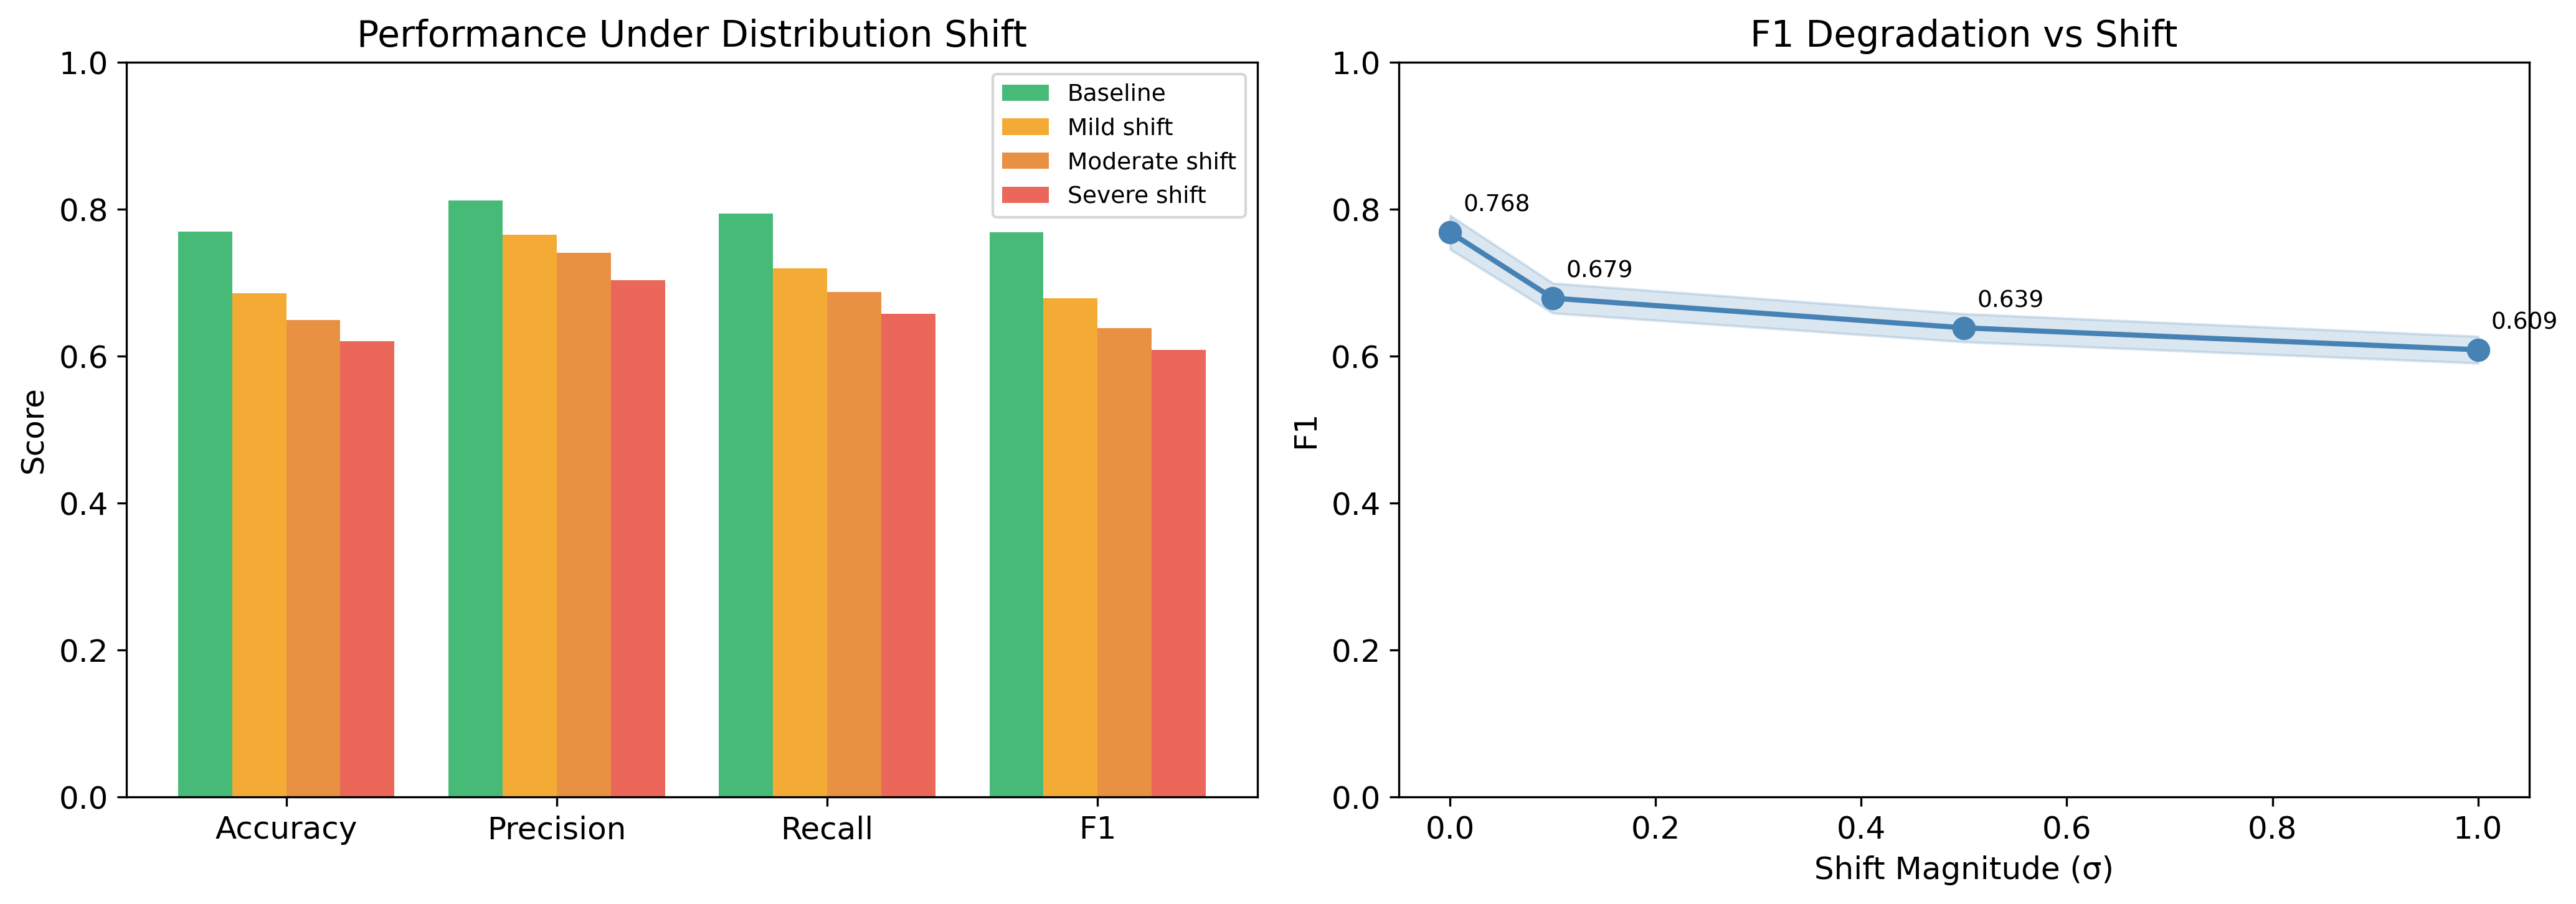

✅ Fig 5 saved


In [7]:
# CELL 7 — Fig 5: Distribution shift
slabels = [s.split('(')[0].strip() for s in shift_results['scenario']]
sc_colors = ['#27ae60','#f39c12','#e67e22','#e74c3c']
fig, axes = plt.subplots(1,2,figsize=(14,5))
x = np.arange(4); w = 0.2
for i,(_,row) in enumerate(shift_results.iterrows()):
    axes[0].bar(x+i*w,[row[m] for m in ['accuracy','precision','recall','f1']],w,label=slabels[i],color=sc_colors[i],alpha=0.85)
axes[0].set_xticks(x+w*1.5); axes[0].set_xticklabels(['Accuracy','Precision','Recall','F1'])
axes[0].set_ylabel('Score'); axes[0].set_title('Performance Under Distribution Shift')
axes[0].legend(fontsize=9); axes[0].set_ylim(0,1)
nv = shift_results['noise_std'].values; fv = shift_results['f1'].values
axes[1].plot(nv,fv,'o-',color='steelblue',linewidth=2,markersize=8)
axes[1].fill_between(nv,fv*0.97,fv*1.03,alpha=0.2,color='steelblue')
axes[1].set_xlabel('Shift Magnitude (σ)'); axes[1].set_ylabel('F1'); axes[1].set_title('F1 Degradation vs Shift'); axes[1].set_ylim(0,1)
for xv,yv,lb in zip(nv,fv,slabels): axes[1].annotate(f'{yv:.3f}',(xv,yv),xytext=(5,8),textcoords='offset points',fontsize=9)
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig5_dataset_comparison.png',bbox_inches='tight')
plt.show(); print('✅ Fig 5 saved')

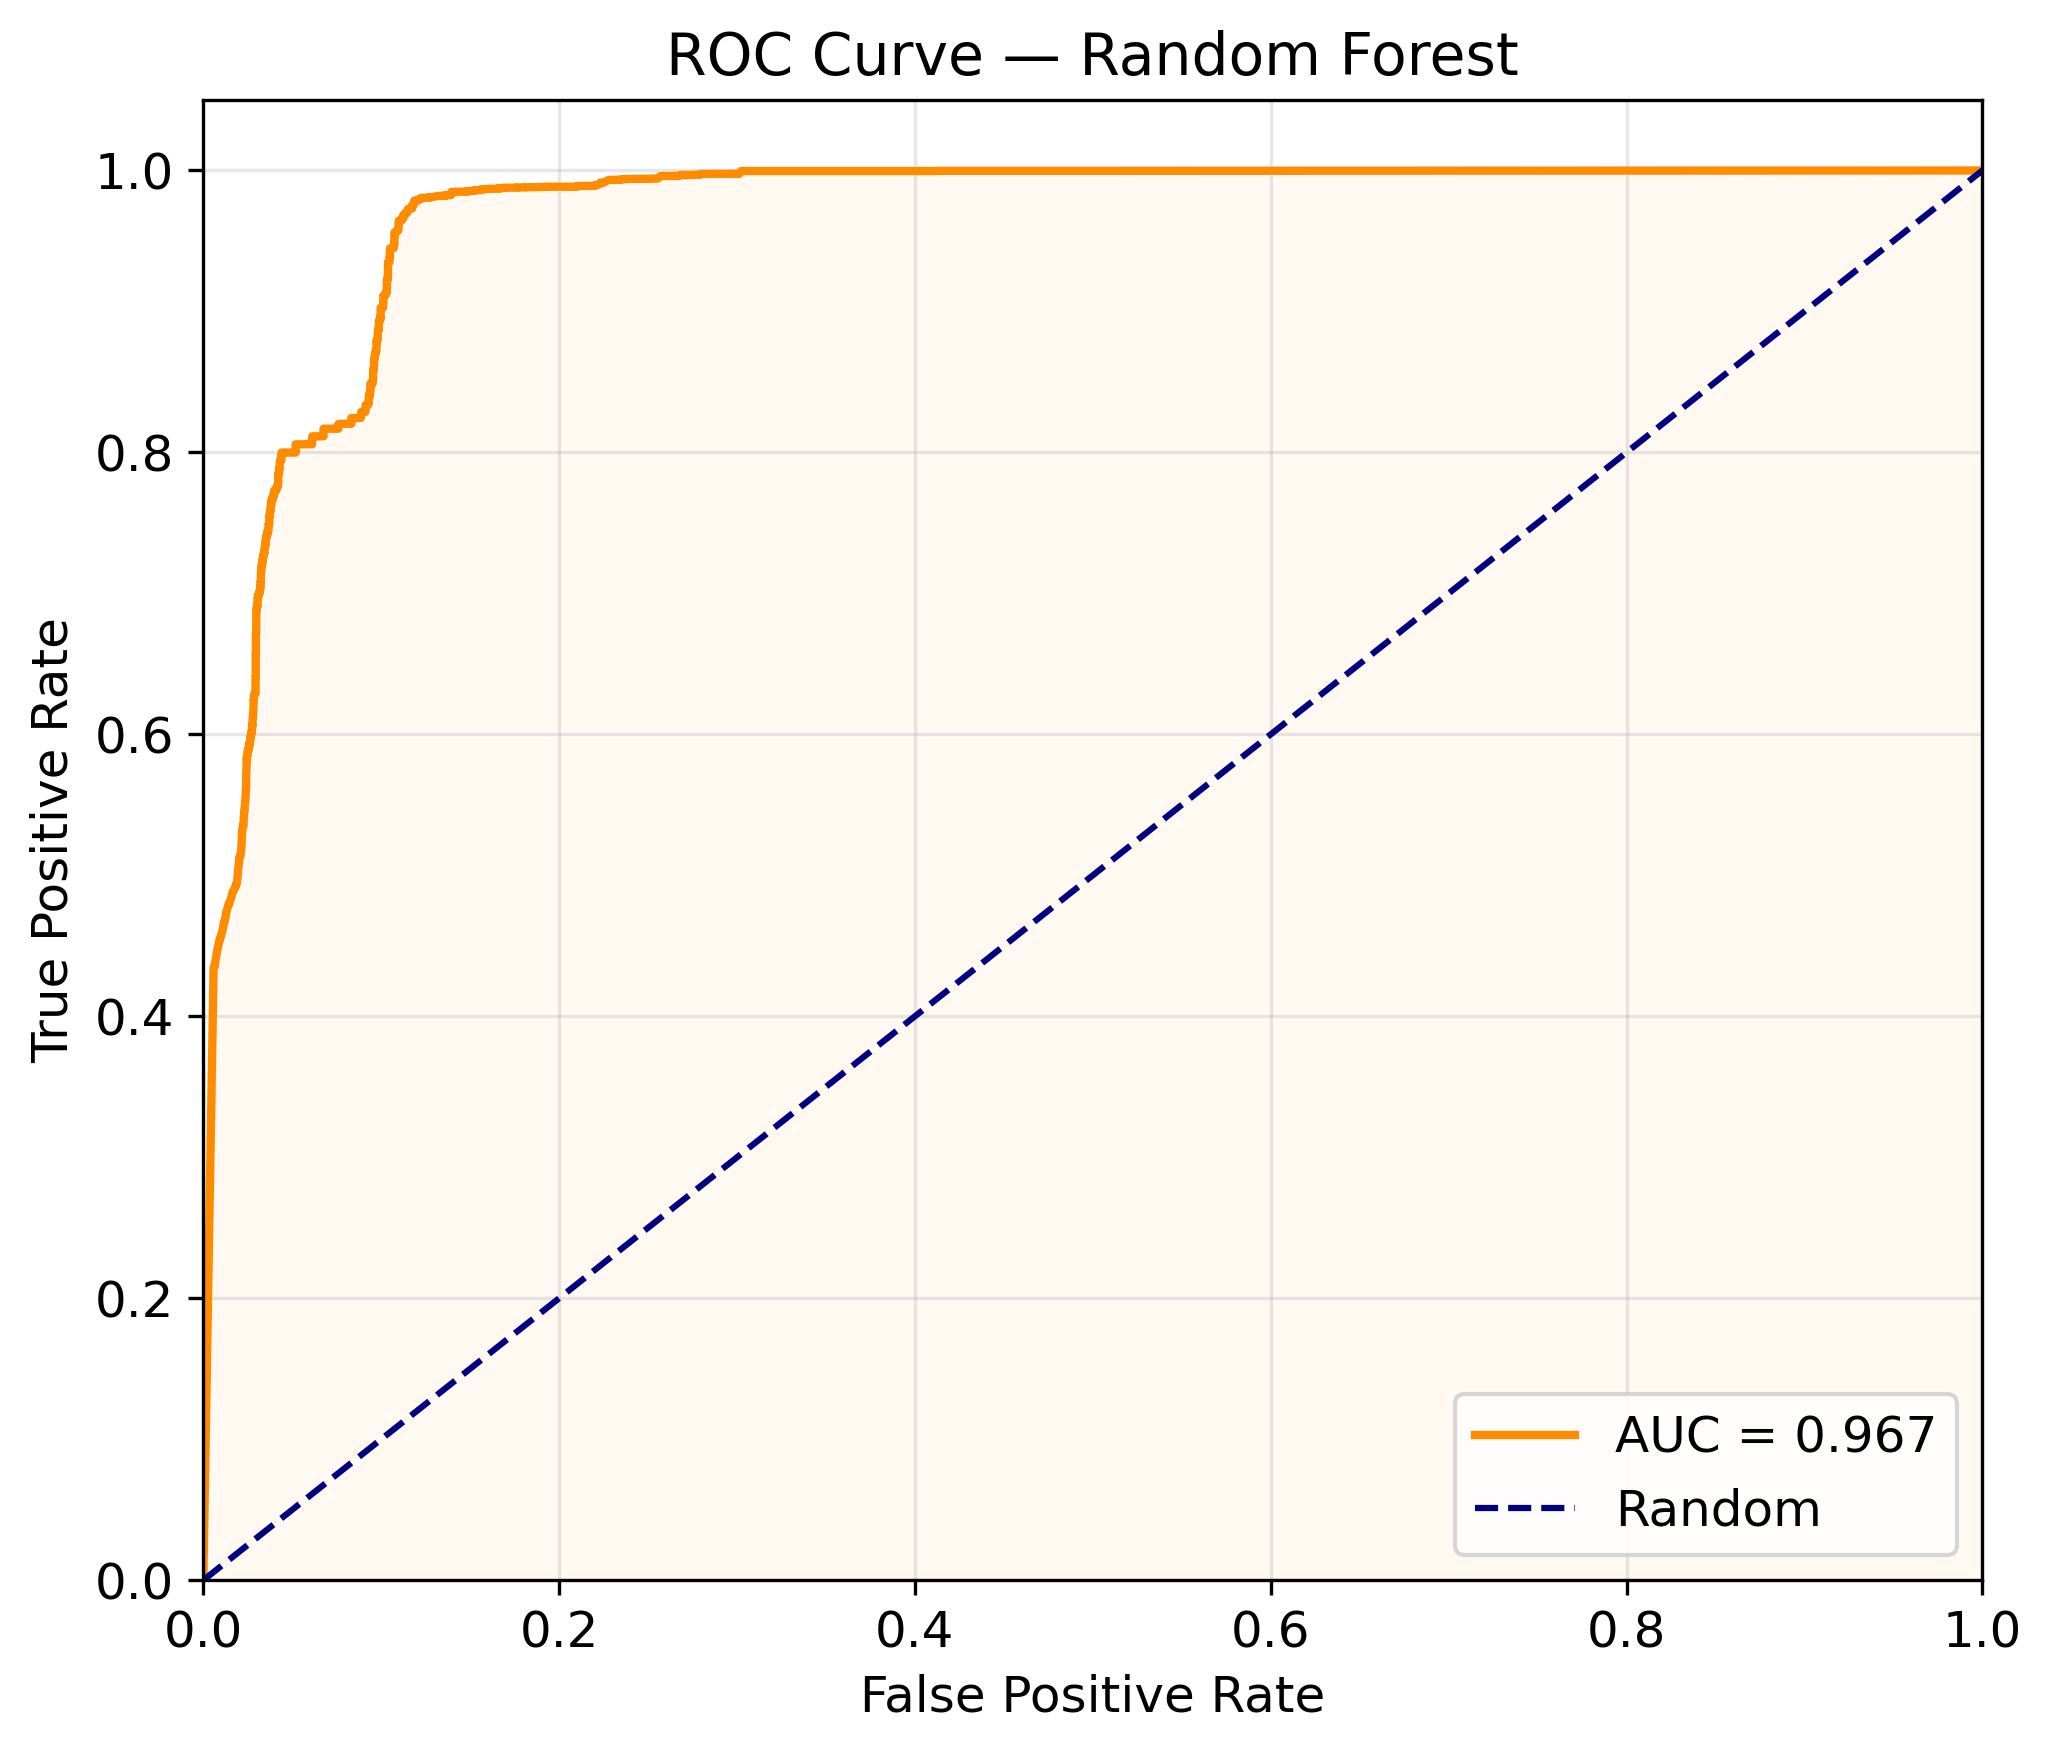

✅ Fig 6 saved | AUC=0.9674


In [8]:
# CELL 8 — Fig 6: ROC curve
y_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0,1],[0,1], color='navy', lw=1.5, linestyle='--', label='Random')
ax.fill_between(fpr, tpr, alpha=0.05, color='darkorange')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig6_roc_curve.png',bbox_inches='tight')
plt.show(); print(f'✅ Fig 6 saved | AUC={roc_auc:.4f}')

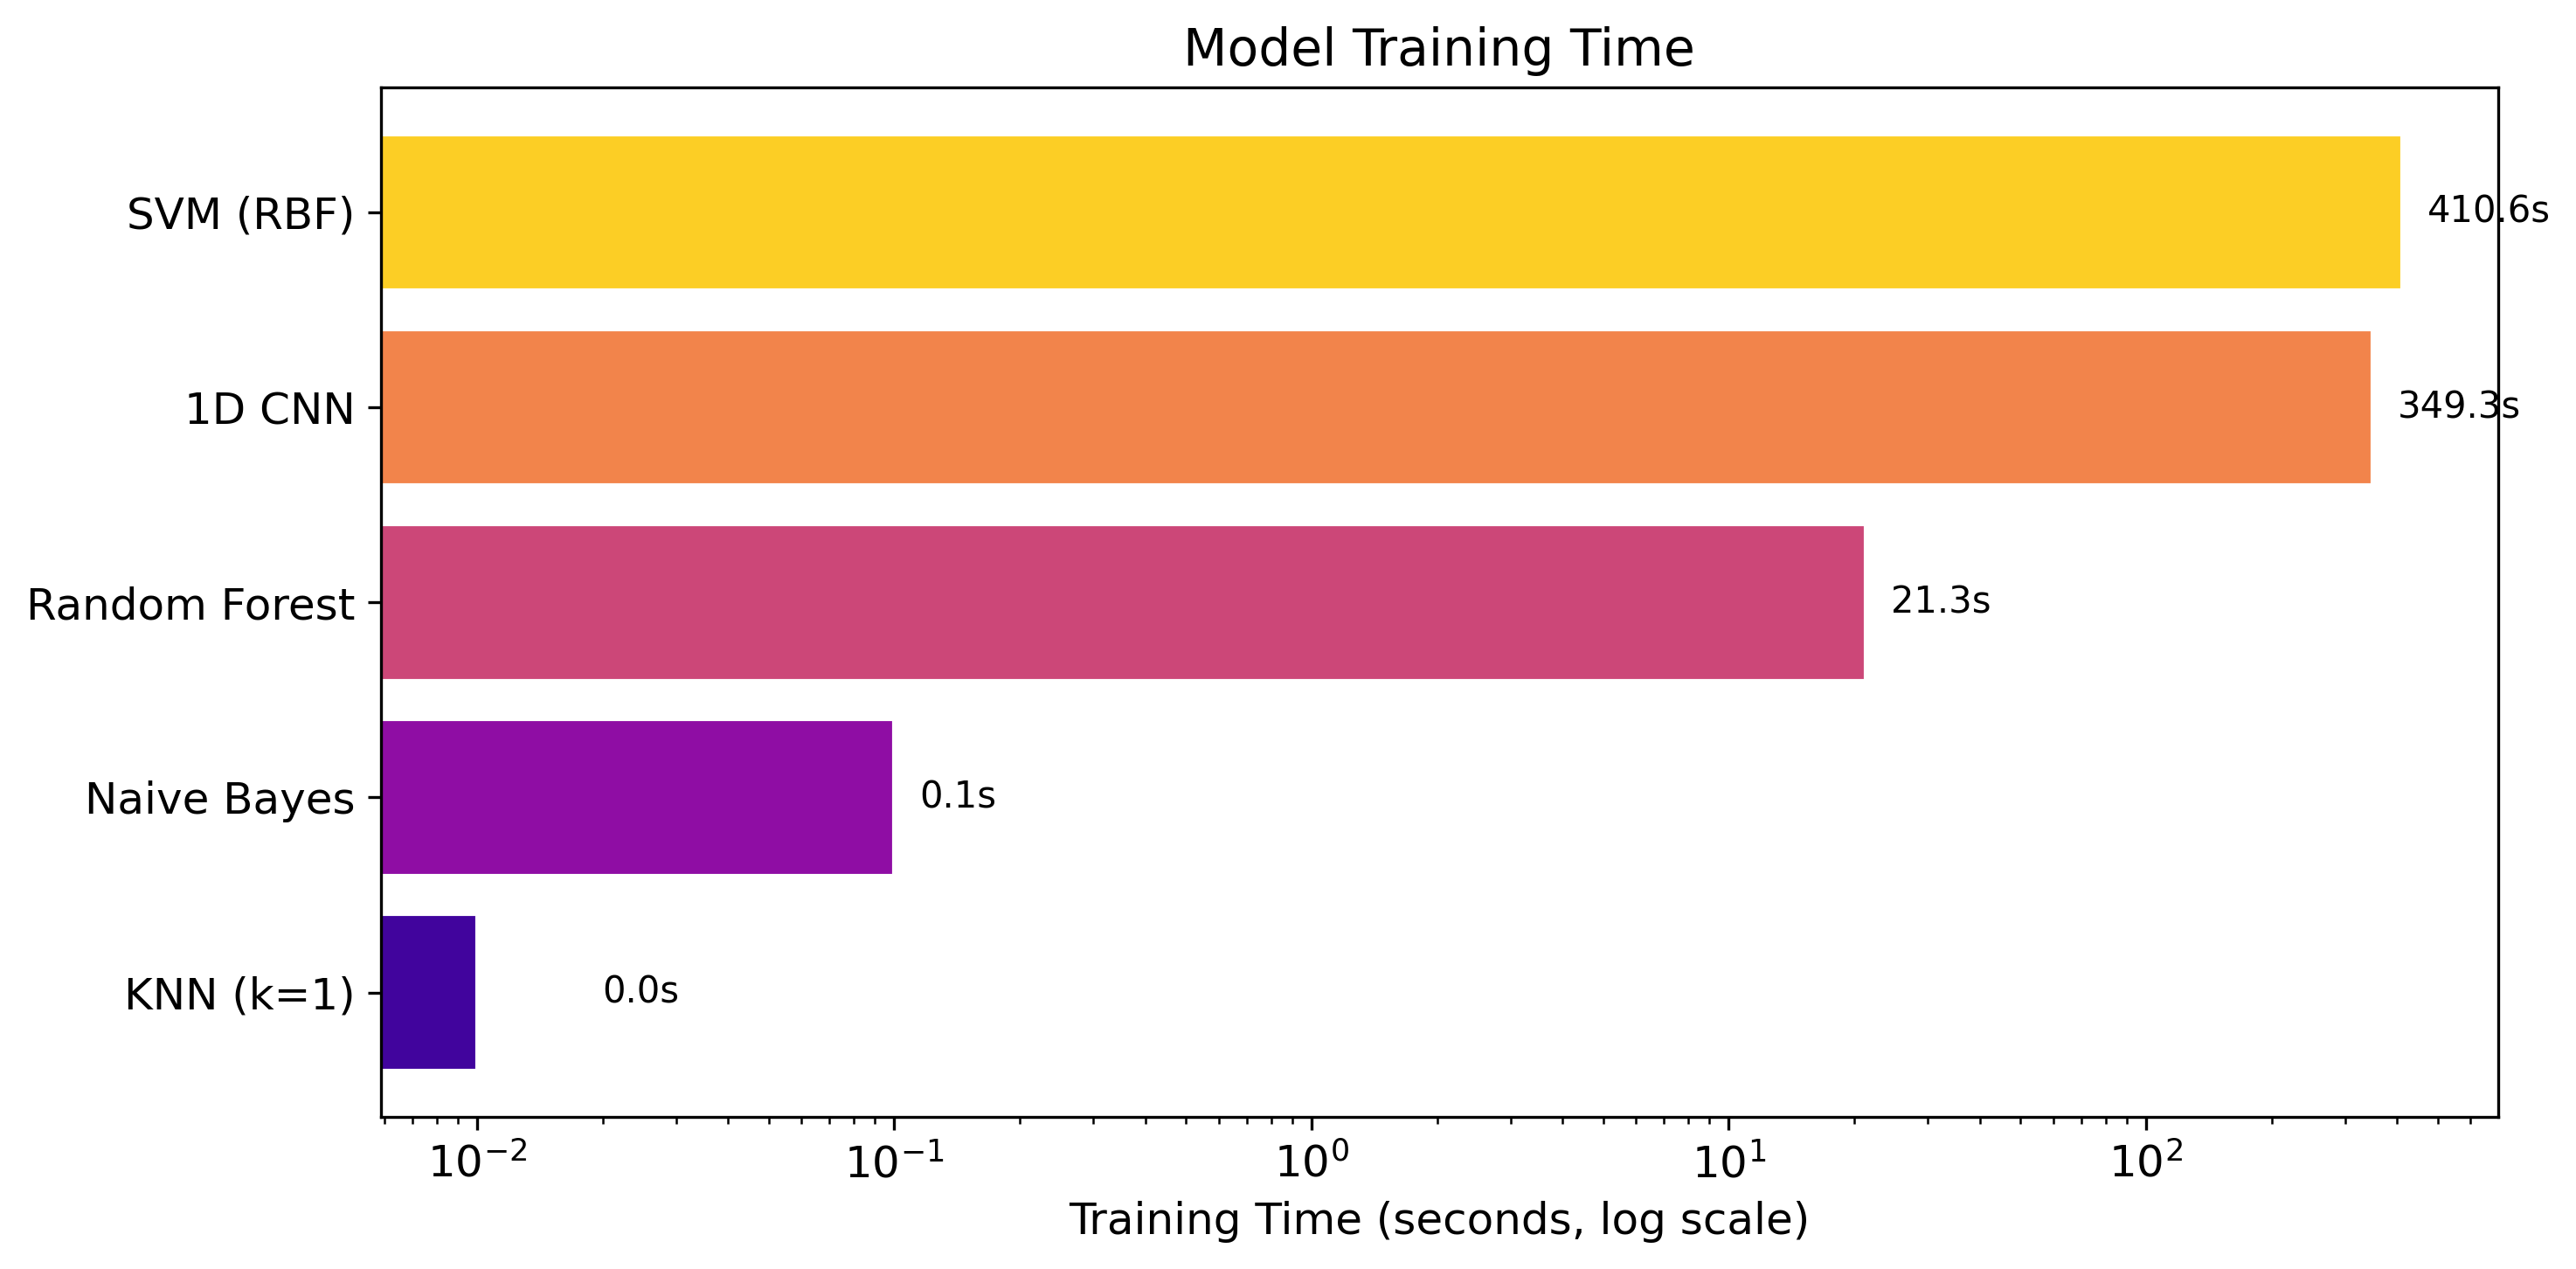

✅ Fig 7 saved


In [9]:
# CELL 9 — Fig 7: Training time
mc_t = model_comparison.copy()
mc_t['t_num'] = pd.to_numeric(mc_t['train_time'], errors='coerce').fillna(0)
mc_t = mc_t.sort_values('t_num')
fig, ax = plt.subplots(figsize=(10,5))
colors_t = plt.cm.plasma(np.linspace(0.1,0.9,len(mc_t)))
bars = ax.barh(mc_t['model'], mc_t['t_num'], color=colors_t, edgecolor='white')
ax.set_xlabel('Training Time (seconds, log scale)'); ax.set_title('Model Training Time')
ax.set_xscale('log')
for bar, t in zip(bars, mc_t['t_num']):
    ax.text(max(t*1.15,0.02), bar.get_y()+bar.get_height()/2, f'{t:.1f}s' if t>0 else 'N/A', va='center', fontsize=10)
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig7_training_time.png',bbox_inches='tight')
plt.show(); print('✅ Fig 7 saved')

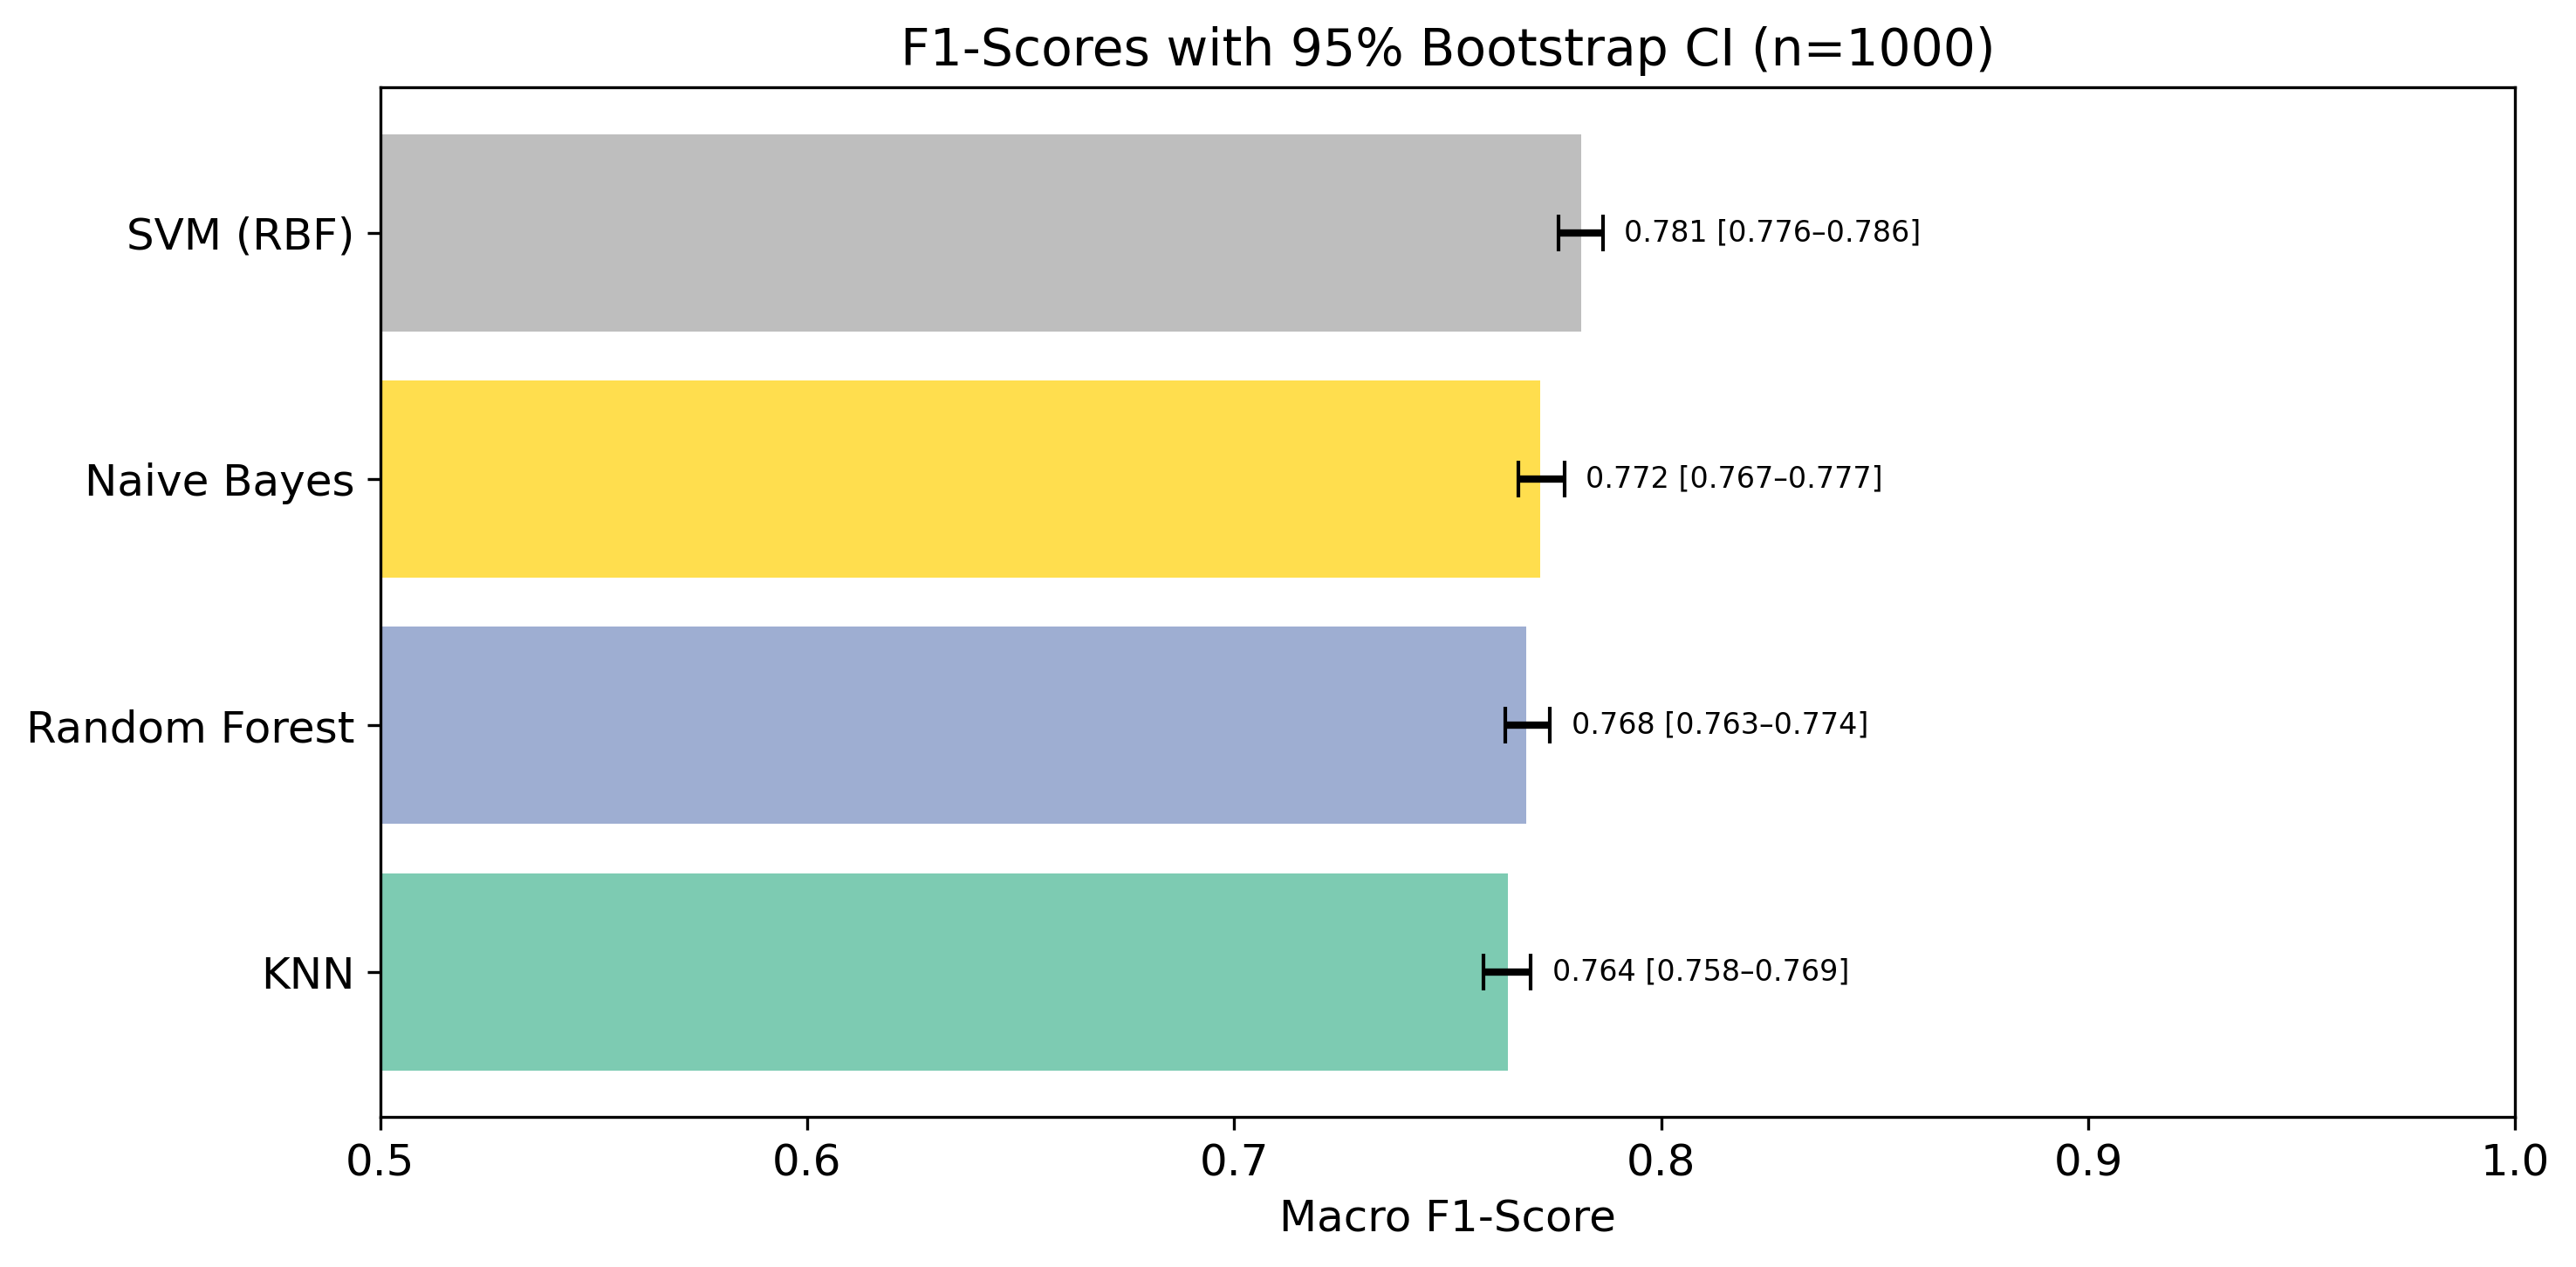

✅ Fig 8 saved


In [10]:
# CELL 10 — Fig 8: Bootstrap CI
bc = bootstrap_ci.sort_values('f1')
errs = [[r['f1']-r['ci_lower'] for _,r in bc.iterrows()],[r['ci_upper']-r['f1'] for _,r in bc.iterrows()]]
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(bc['model'], bc['f1'], xerr=errs, color=plt.cm.Set2(np.linspace(0,1,len(bc))),
        capsize=5, alpha=0.85, error_kw={'linewidth':2})
ax.set_xlabel('Macro F1-Score'); ax.set_title('F1-Scores with 95% Bootstrap CI (n=1000)'); ax.set_xlim(0.5,1.0)
for _,row in bc.iterrows():
    ax.text(row['ci_upper']+0.005, list(bc['model']).index(row['model']),
            f"{row['f1']:.3f} [{row['ci_lower']:.3f}–{row['ci_upper']:.3f}]", va='center', fontsize=8)
plt.tight_layout(); plt.savefig(f'{BASE}/results/figures/report_fig8_bootstrap_ci.png',bbox_inches='tight')
plt.show(); print('✅ Fig 8 saved')

In [11]:
# CELL 11 — Final summary table
best_model = model_comparison.loc[model_comparison['test_f1'].idxmax(),'model']
drop = shift_results.iloc[0]['f1'] - shift_results.iloc[-1]['f1']
summary = pd.DataFrame({
    'Metric':['Best Model','Best Test F1','AUC','SHAP vs LIME (τ)','Baseline F1','Severe Shift F1','F1 Drop'],
    'Value':[
        best_model,
        f"{model_comparison['test_f1'].max():.4f}",
        f'{roc_auc:.4f}',
        f"{xai_comparison['kendall_tau'].mean():.4f} ± {xai_comparison['kendall_tau'].std():.4f}",
        f"{shift_results.iloc[0]['f1']:.4f}",
        f"{shift_results.iloc[-1]['f1']:.4f}",
        f'{drop:.4f}'
    ]
})
print(summary.to_string(index=False))
summary.to_csv(f'{BASE}/results/metrics/report_summary.csv', index=False)
print('✅ All figures and summary saved')

          Metric           Value
      Best Model          1D CNN
    Best Test F1          0.7886
             AUC          0.9674
SHAP vs LIME (τ) 0.3165 ± 0.3024
     Baseline F1          0.7685
 Severe Shift F1          0.6087
         F1 Drop          0.1597
✅ All figures and summary saved
